# inference_noisebest

Noise-model inference checks for the **original** noise model (`biasnoisenest`), with `bx=32`, `n_train=10000`, `_best-rand30` checkpoints.

**Fiducial statistics:** $P_{gg}$; $P_{gg}+P_{gm}$; $P_{gg}+B$ ($k_\text{max}^\text{bispec}=0.25$); $P_{gg}+B+P_{gm}$ (bispec $k_\text{max}^\text{bispec}=0.25$).

**Sections:** SHAMe OOD mock; fixed-cosmo mean with `noisebest` test bias; $k_\mathrm{max}$ sweep triangles ($P_{gg}+P_{gm}$, $P_{gg}+B$, $P_{gg}+B+P_{gm}$ grid); individual SHAMe phases ($\phi=0$, $\phi=\pi$).


In [13]:
import sys
from pathlib import Path

try:
    REPO_ROOT = Path(__file__).resolve().parents[1]
except NameError:
    REPO_ROOT = Path.cwd()
    if REPO_ROOT.name == "notebooks":
        REPO_ROOT = REPO_ROOT.parent

sys.path.insert(0, str(REPO_ROOT / "code"))

import numpy as np
import matplotlib.colors as mcolors
from matplotlib import pyplot as plt

import paths
import plotter
import data_loader
import generate_params as genp
import utils_plot

%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [14]:
# Shared configuration
bx = 32
n_train = 10000
TAG_INF_BEST_SUFFIX = "_best-rand30"

data_mode = "muchisimocks"
TAG_PARAMS_TRAIN = "_p5_n10000"
TAG_BIASPARAMS_TRAIN = "_biasnoisenest_p9_n320000"
TAG_NOISE_TRAIN = "_noise_unit_p5_n10000"
tag_reparam = "_rp"

# Fiducial statistics (same for noisem2, noisenest, fixed-cosmo tests, etc.)
STATISTICS_ARR_FID = [
    ["pk"],
    ["pk", "pgm"],
    ["pk", "bispec"],
    ["pk", "bispec", "pgm"],
]
TAGS_MASK_FID = ["", "", "_kb0.25", "_kb0.25"]

# kpgm scale-cut comparisons (separate triangle plots only)
STATISTICS_ARR_CMP_PGM = [["pk", "pgm"], ["pk", "pgm"]]
TAGS_MASK_CMP_PGM = ["", "_kpgm0.25"]

STATISTICS_ARR_CMP_BSPEC_PGM = [["pk", "bispec", "pgm"], ["pk", "bispec", "pgm"]]
TAGS_MASK_CMP_BSPEC_PGM = ["_kb0.25", "_kb0.25_kpgm0.25"]

# Fixed-cosmo test tags
TAG_PARAMS_TEST_FIXED = "_shame_p0_n1000"
TAG_BIASPARAMS_TEST = "_bias_shame_noisebest_p0_n1"
TAG_NOISE_TEST_FIXED = "_noise_unit_shame_p0_n1000"
TAG_DATAGEN_TEST_MEAN = "_mean"

DATA_MODE_TEST_SHAME = "shame"
TAG_MOCK_SHAME = "_nbar0.00022"
NBAR_LABEL = "0.00022"

PARAM_NAMES_ZOOM = ["omega_cold", "sigma8_cold", "b1"]
idx_obs = 0

extents = {**genp.get_bounds("cosmo"), **genp.get_bounds("bias")}
extents_mid = extents.copy()
extents_mid["b1"] = [-0.4, 1.4]
extents_narrow = extents.copy()
extents_narrow["b1"] = [0.2, 0.7]
extents_noisebest_fid = extents_narrow.copy()
FIGSIZE_CORNER = (5, 5)
FIGSIZE_ALL_PARAMS = (9, 9)
FONTSIZE_LEGEND = 12
KMAX_DEFAULT = 0.4
FIDUCIAL_KMAX_BISPEC = 0.25
FIDUCIAL_KMAX_PGM = KMAX_DEFAULT
ANOISE_OPTION = "Anmult"
LOC_LEGEND = (1.02, 0.98)
dir_sbi = paths.DIR_RESULTS / "results_sbi"

STAT_ROW_PGM = ["pk", "pgm"]
STAT_ROW_KB = ["pk", "bispec"]
STAT_ROW_BPGM = ["pk", "bispec", "pgm"]

# 1D sweeps (0.1 → loose); 2D grid (0.2 → loose) for pk+bispec+pgm
TAGS_KMAX_KPGM_1D = ["_kpgm0.1", "_kpgm0.15", "_kpgm0.2", "_kpgm0.25", "_kpgm0.3", "_kpgm0.35", ""]
TAGS_KMAX_KB_1D = ["_kb0.1", "_kb0.15", "_kb0.2", "_kb0.25", "_kb0.3", "_kb0.35", ""]
TAG_GRID_KB = ["_kb0.2", "_kb0.25", "_kb0.3", "_kb0.35", ""]
TAG_GRID_KPGM = ["_kpgm0.2", "_kpgm0.25", "_kpgm0.3", "_kpgm0.35", ""]


def join_kmax_masks(tag_kb="", tag_kpgm=""):
    return f"{tag_kb}{tag_kpgm}"


def _kmax_focus_label(tags_mask, focus):
    return _kmax_cmp_legend_label(tags_mask, focus=focus)


def setup_fixed_mean_sweep(statistics_row, tags_mask_list):
    statistics_arr = [statistics_row] * len(tags_mask_list)
    tags_inf, labels, colors = setup_inference(
        TAG_BIASPARAMS_TRAIN, statistics_arr, tags_mask_list,
    )
    cosmo_vary, bias_vary, param_vary = utils_plot.load_training_params(
        TAG_PARAMS_TRAIN, TAG_BIASPARAMS_TRAIN, bx=bx,
    )
    stat_suffix = tag_stats_test_arr([statistics_row])[0]
    tags_test = utils_plot.setup_test_tags(
        data_mode=data_mode,
        tag_params_test=TAG_PARAMS_TEST_FIXED,
        tags_biasparams_test=TAG_BIASPARAMS_TEST,
        tag_stats_arr=[stat_suffix] * len(tags_mask_list),
        tag_noise_test=TAG_NOISE_TEST_FIXED,
        tag_datagen_test=TAG_DATAGEN_TEST_MEAN,
        tags_mask_test=tags_mask_list,
    )
    keep = samples_exist(tags_inf, tags_test)
    theta = data_loader.load_theta_test(
        TAG_PARAMS_TEST_FIXED,
        TAG_BIASPARAMS_TEST,
        cosmo_param_names_vary=cosmo_vary,
        bias_param_names_vary=bias_vary,
    )
    theta_obs = theta[idx_obs] if theta.ndim == 2 else theta
    idxs_zoom = [param_vary.index(pn) for pn in PARAM_NAMES_ZOOM]
    return tags_inf, labels, colors, tags_test, keep, theta_obs, theta_obs[idxs_zoom]


def plot_kmax_sweep_fixed(
    statistics_row,
    tags_mask_list,
    title,
    theta_show,
    *,
    kmax_focus="pgm",
    extents=None,
):
    """Overlay all available k_max cuts on one triangle (fixed-cosmo mean, plasma colors)."""
    if extents is None:
        extents = extents_narrow
    tags_inf, labels, colors, tags_test, keep, _, _ = setup_fixed_mean_sweep(
        statistics_row, tags_mask_list,
    )
    print_available(title + " — availability:", labels, tags_inf, tags_test, keep)
    idxs = _select_available(range(len(keep)), keep)
    if not idxs:
        print(f"No samples on disk for: {title}")
        _print_missing(tags_inf, tags_test, labels, keep)
        return
    plotter.plot_contours_inf(
        param_names=PARAM_NAMES_ZOOM,
        idx_obs=idx_obs,
        theta_obs_true=theta_show,
        inf_methods=["sbi"] * len(idxs),
        tags_inf=[tags_inf[i] for i in idxs],
        tags_test=[tags_test[i] for i in idxs],
        colors=pp_style_colors(len(idxs)),
        labels=_kmax_cmp_legend_labels(tags_mask_list, idxs, focus=kmax_focus),
        title=title,
        extents=extents,
        figsize=FIGSIZE_CORNER,
        fontsize_legend=FONTSIZE_LEGEND,
        loc_legend=LOC_LEGEND,
        unreparameterize=True,
    )

def tag_stats_arr(statistics_arr, tags_mask):
    """Stat suffix with mask appended (train tags, SHAMe OOD)."""
    return [f'_{"_".join(s)}' + m for s, m in zip(statistics_arr, tags_mask)]

def tag_stats_test_arr(statistics_arr):
    """Base stat suffix only; masks go to setup_test_tags separately."""
    return [f'_{"_".join(s)}' for s in statistics_arr]

def sample_fn(tag_inf, tag_test):
    return dir_sbi / f"sbi{tag_inf}" / f"samples_test{tag_test}_pred.npy"

def samples_exist(tags_inf, tags_test):
    return [sample_fn(ti, tt).exists() for ti, tt in zip(tags_inf, tags_test)]

def print_available(title, labels, tags_inf, tags_test, keep):
    print(title)
    for lbl, k, ti, tt in zip(labels, keep, tags_inf, tags_test):
        print(f"  [{'x' if k else ' '}] {lbl}")
        if not k:
            print(f"       missing: {sample_fn(ti, tt)}")

def _print_missing(tags_inf, tags_test, labels, keep, idxs=None):
    for i in (idxs if idxs is not None else range(len(keep))):
        if i < len(keep) and not keep[i]:
            print(f"  missing [{labels[i]}]: {sample_fn(tags_inf[i], tags_test[i])}")

def setup_inference(tag_biasparams_train, statistics_arr, tags_mask):
    tags_inf, labels, colors, _ = utils_plot.setup_inference_tags(
        data_mode=data_mode,
        tag_params=TAG_PARAMS_TRAIN,
        tag_biasparams=tag_biasparams_train,
        statistics_arr=statistics_arr,
        bx=bx,
        tag_noise=TAG_NOISE_TRAIN,
        tag_reparam=tag_reparam,
        n_train=n_train,
        tags_mask=tags_mask,
    )
    tags_inf = [t + TAG_INF_BEST_SUFFIX for t in tags_inf]
    return tags_inf, labels, colors

def pp_style_colors(n_chains):
    """Reversed plasma, matching kmax PP / coverage plots."""
    return [
        mcolors.to_hex(c)
        for c in plt.cm.plasma_r(np.linspace(0.25, 0.95, max(n_chains, 1)))
    ]


def _kmax_cmp_legend_label(tags_mask, *, focus="pgm"):
    for mask_part in tags_mask.split("_"):
        if not mask_part:
            continue
        if focus == "pgm" and mask_part.startswith("kpgm"):
            return rf"$k_\text{{max}}^\text{{pgm}}={float(mask_part[len('kpgm'):])}$"
        if focus == "bispec" and mask_part.startswith("kb"):
            return rf"$k_\text{{max}}^\text{{bispec}}={float(mask_part[len('kb'):])}$"
    if focus == "pgm":
        return rf"$k_\text{{max}}^\text{{pgm}}={KMAX_DEFAULT}$"
    if focus == "bispec":
        return rf"$k_\text{{max}}^\text{{bispec}}={KMAX_DEFAULT}$"
    ml = utils_plot.get_mask_label(tags_mask)
    return ml if ml else rf"$k_\text{{max}}={KMAX_DEFAULT}$"


def _kmax_cmp_legend_labels(tags_mask, idxs, focus="pgm"):
    return [_kmax_cmp_legend_label(tags_mask[i], focus=focus) for i in idxs]


def _fiducial_title_with_kmax(title):
    sub = (
        rf"$k_\text{{max}}^\text{{bispec}}={FIDUCIAL_KMAX_BISPEC}$, "
        rf"$k_\text{{max}}^\text{{pgm}}={FIDUCIAL_KMAX_PGM}$"
    )
    return f"{title}\n{sub}"

def setup_shame_ood(tag_biasparams_train, statistics_arr, tags_mask, tag_mock=TAG_MOCK_SHAME):
    tags_inf, labels, colors = setup_inference(tag_biasparams_train, statistics_arr, tags_mask)
    cosmo_vary, bias_vary, param_vary = utils_plot.load_training_params(
        TAG_PARAMS_TRAIN, tag_biasparams_train, bx=bx,
    )
    tags_test = utils_plot.setup_shame_mock_test_tags(
        tag_stats_arr=tag_stats_arr(statistics_arr, tags_mask),
        data_mode_test=DATA_MODE_TEST_SHAME,
        tag_mock=tag_mock,
    )
    keep = samples_exist(tags_inf, tags_test)
    return tags_inf, labels, colors, tags_test, keep, cosmo_vary, bias_vary, param_vary

def setup_fixed_mean(tag_biasparams_train, tag_biasparams_test, statistics_arr, tags_mask):
    tags_inf, labels, colors = setup_inference(tag_biasparams_train, statistics_arr, tags_mask)
    cosmo_vary, bias_vary, param_vary = utils_plot.load_training_params(
        TAG_PARAMS_TRAIN, tag_biasparams_train, bx=bx,
    )
    tags_test = utils_plot.setup_test_tags(
        data_mode=data_mode,
        tag_params_test=TAG_PARAMS_TEST_FIXED,
        tags_biasparams_test=tag_biasparams_test,
        tag_stats_arr=tag_stats_test_arr(statistics_arr),
        tag_noise_test=TAG_NOISE_TEST_FIXED,
        tag_datagen_test=TAG_DATAGEN_TEST_MEAN,
        tags_mask_test=tags_mask,
    )
    keep = samples_exist(tags_inf, tags_test)
    theta = data_loader.load_theta_test(
        TAG_PARAMS_TEST_FIXED,
        tag_biasparams_test,
        cosmo_param_names_vary=cosmo_vary,
        bias_param_names_vary=bias_vary,
    )
    theta_obs = theta[idx_obs] if theta.ndim == 2 else theta
    idxs_zoom = [param_vary.index(pn) for pn in PARAM_NAMES_ZOOM]
    return tags_inf, labels, colors, tags_test, keep, theta_obs, theta_obs[idxs_zoom], param_vary

def _select_available(idxs, keep):
    return [i for i in idxs if keep[i]]

def plot_fiducial_triangle(
    tags_inf, labels, colors, tags_test, keep, title, theta_show, *,
    tags_mask, extents=None,
):
    """All fiducial statistics on one triangle plot (color_dict_statistics)."""
    idxs = _select_available(range(len(keep)), keep)
    if not idxs:
        print(f"No fiducial samples on disk for: {title}")
        _print_missing(tags_inf, tags_test, labels, keep)
        return
    if extents is None:
        extents = extents_noisebest_fid
    plot_title = _fiducial_title_with_kmax(title)
    plotter.plot_contours_inf(
        param_names=PARAM_NAMES_ZOOM,
        idx_obs=idx_obs,
        theta_obs_true=theta_show,
        inf_methods=["sbi"] * len(idxs),
        tags_inf=[tags_inf[i] for i in idxs],
        tags_test=[tags_test[i] for i in idxs],
        colors=[colors[i] for i in idxs],
        labels=[labels[i] for i in idxs],
        title=plot_title,
        extents=extents,
        figsize=FIGSIZE_CORNER,
        fontsize_legend=FONTSIZE_LEGEND,
        loc_legend=LOC_LEGEND,
        unreparameterize=True,
    )

def plot_kpgm_cmp_triangle(
    tags_inf, labels, colors, tags_test, keep, title, theta_show, *,
    tags_mask, cmp_idxs=(0, 1), kmax_focus="pgm",
):
    """Compare two scale cuts (plasma colors, legend = k_max only)."""
    idxs = [i for i in cmp_idxs if i < len(keep) and keep[i]]
    if len(idxs) < 1:
        print(f"No samples on disk for: {title}")
        _print_missing(tags_inf, tags_test, labels, keep, cmp_idxs)
        return
    plotter.plot_contours_inf(
        param_names=PARAM_NAMES_ZOOM,
        idx_obs=idx_obs,
        theta_obs_true=theta_show,
        inf_methods=["sbi"] * len(idxs),
        tags_inf=[tags_inf[i] for i in idxs],
        tags_test=[tags_test[i] for i in idxs],
        colors=pp_style_colors(len(idxs)),
        labels=_kmax_cmp_legend_labels(tags_mask, idxs, focus=kmax_focus),
        title=title,
        extents=extents_narrow,
        figsize=FIGSIZE_CORNER,
        fontsize_legend=FONTSIZE_LEGEND,
        loc_legend=LOC_LEGEND,
        unreparameterize=True,
    )


def _extents_all_params():
    return {
        **genp.get_bounds("cosmo"),
        **genp.get_bounds("bias"),
        **genp.get_bounds("Anoise", anoise_option=ANOISE_OPTION),
    }


def plot_all_params_fiducial(
    tags_inf, labels, colors, tags_test, keep, title, theta_obs, param_vary, *,
    extents=None,
):
    """All varied parameters, all fiducial statistics on one corner plot."""
    idxs = _select_available(range(len(keep)), keep)
    if not idxs:
        print(f"No samples on disk for all-params plot: {title}")
        _print_missing(tags_inf, tags_test, labels, keep)
        return
    if extents is None:
        extents = _extents_all_params()
    plotter.plot_contours_inf(
        param_names=list(param_vary),
        idx_obs=idx_obs,
        theta_obs_true=theta_obs,
        inf_methods=["sbi"] * len(idxs),
        tags_inf=[tags_inf[i] for i in idxs],
        tags_test=[tags_test[i] for i in idxs],
        colors=[colors[i] for i in idxs],
        labels=[labels[i] for i in idxs],
        title=title,
        extents=extents,
        figsize=FIGSIZE_ALL_PARAMS,
        fontsize_legend=FONTSIZE_LEGEND,
        loc_legend=LOC_LEGEND,
        unreparameterize=True,
    )


# SHAMe OOD — noisenest

## Contours

In [16]:
(
    tags_inf_ood, labels_ood, colors_ood, tags_test_ood, keep_ood,
    cosmo_vary, bias_vary, param_vary,
) = setup_shame_ood(TAG_BIASPARAMS_TRAIN, STATISTICS_ARR_FID, TAGS_MASK_FID)
inf_ood = ["sbi"] * len(tags_inf_ood)
print_available("SHAMe OOD, noisenest — fiducial:", labels_ood, tags_inf_ood, tags_test_ood, keep_ood)

theta_ood = data_loader.load_theta_ood(
    DATA_MODE_TEST_SHAME, TAG_MOCK_SHAME,
    cosmo_param_names_vary=cosmo_vary, bias_param_names_vary=bias_vary,
)
theta_obs = theta_ood[idx_obs] if theta_ood.ndim == 2 else theta_ood
theta_zoom = theta_obs[[param_vary.index(pn) for pn in PARAM_NAMES_ZOOM]]


SHAMe OOD, noisenest — fiducial:
  [x] $P_\mathrm{gg}(k)$
  [x] $P_\mathrm{gg}(k)$ + $P_\mathrm{gm}(k)$
  [x] $P_\mathrm{gg}(k)$ + $B(k_1,k_2,k_3)$
  [x] $P_\mathrm{gg}(k)$ + $B(k_1,k_2,k_3)$ + $P_\mathrm{gm}(k)$


fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_nbar0.00022_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_pgm_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_pgm_nbar0.00022_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_kb0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_bispec_kb0.25_nbar0.00022_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kb0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_bispec_pgm_kb0.25_nbar0.00022_pred.npy


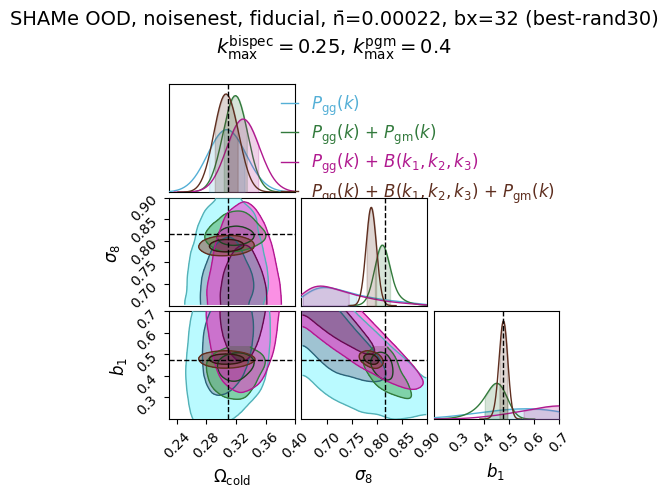

In [8]:
plot_fiducial_triangle(
    tags_inf_ood, labels_ood, colors_ood, tags_test_ood, keep_ood,
    f"SHAMe OOD, noisenest, fiducial, n̄={NBAR_LABEL}, bx={bx} (best-rand30)",
    theta_zoom,
    tags_mask=TAGS_MASK_FID,
)


### All varied parameters (fiducial)


fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_nbar0.00022_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_pgm_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_pgm_nbar0.00022_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_kb0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_bispec_kb0.25_nbar0.00022_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kb0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_bispec_pgm_kb0.25_nbar0.00022_pred.npy


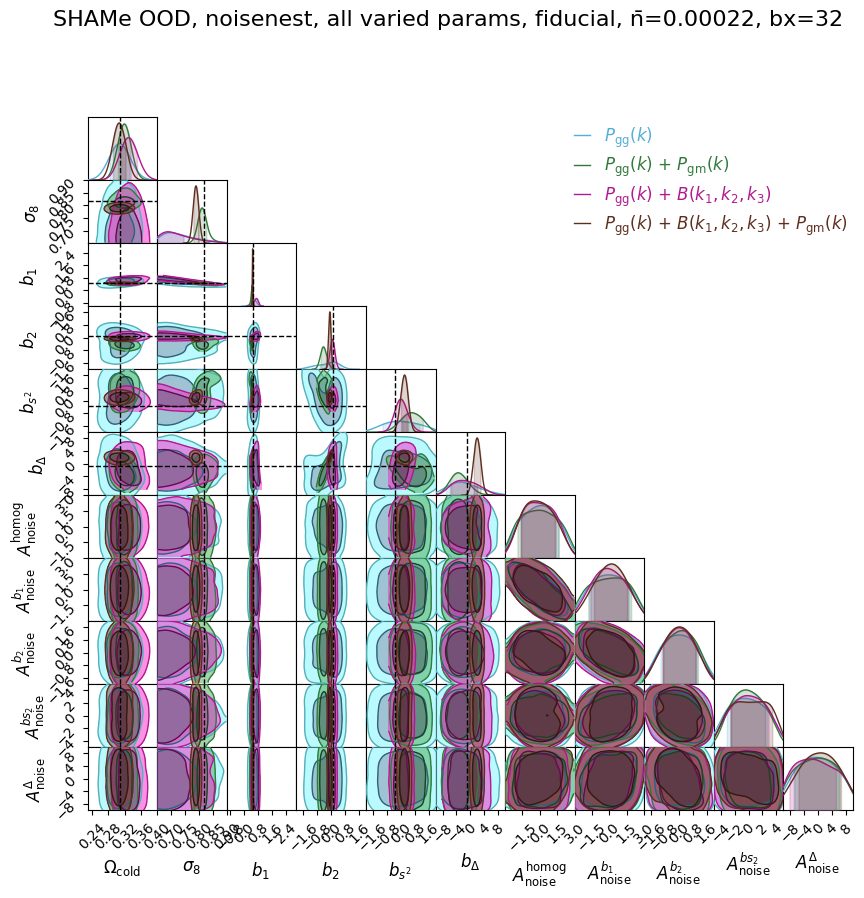

In [17]:
plot_all_params_fiducial(
    tags_inf_ood, labels_ood, colors_ood, tags_test_ood, keep_ood,
    f"SHAMe OOD, noisenest, all varied params, fiducial, n̄={NBAR_LABEL}, bx={bx}",
    theta_obs, param_vary,
)


### $P_{gm}$ scale cut — $P_{gg}+P_{gm}$

SHAMe OOD, noisenest — pk+pgm kpgm compare:
  [x] $P_\mathrm{gg}(k)$ + $P_\mathrm{gm}(k)$
  [x] $P_\mathrm{gg}(k)$ + $P_\mathrm{gm}(k)$
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_pgm_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_pgm_nbar0.00022_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_pgm_kpgm0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_pgm_kpgm0.25_nbar0.00022_pred.npy


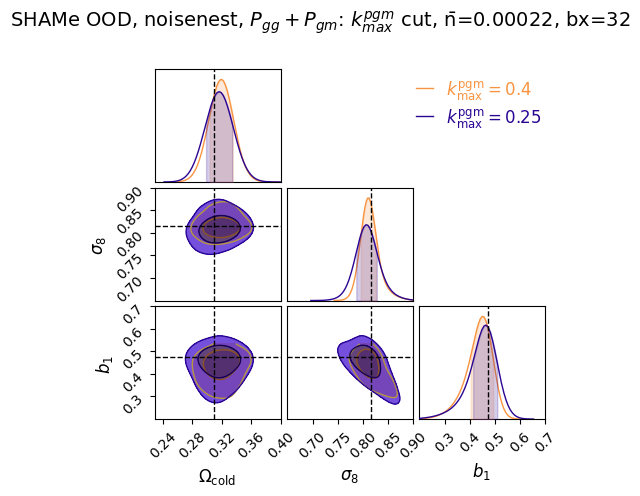

In [9]:
(
    tags_inf_ood_pgm, labels_ood_pgm, colors_ood_pgm, tags_test_ood_pgm, keep_ood_pgm,
    *_,
) = setup_shame_ood(TAG_BIASPARAMS_TRAIN, STATISTICS_ARR_CMP_PGM, TAGS_MASK_CMP_PGM)
print_available("SHAMe OOD, noisenest — pk+pgm kpgm compare:", labels_ood_pgm, tags_inf_ood_pgm, tags_test_ood_pgm, keep_ood_pgm)

plot_kpgm_cmp_triangle(
    tags_inf_ood_pgm, labels_ood_pgm, colors_ood_pgm, tags_test_ood_pgm, keep_ood_pgm,
    f"SHAMe OOD, noisenest, $P_{{gg}}+P_{{gm}}$: $k_{{max}}^{{pgm}}$ cut, n̄={NBAR_LABEL}, bx={bx}",
    theta_zoom,
    tags_mask=TAGS_MASK_CMP_PGM,
)


### $P_{gm}$ scale cut — $P_{gg}+B+P_{gm}$ (bispec $k_\text{max}^\text{bispec}=0.25$)

SHAMe OOD, noisenest — pk+bispec+pgm kpgm compare:
  [x] $P_\mathrm{gg}(k)$ + $B(k_1,k_2,k_3)$ + $P_\mathrm{gm}(k)$
  [x] $P_\mathrm{gg}(k)$ + $B(k_1,k_2,k_3)$ + $P_\mathrm{gm}(k)$
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kb0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_bispec_pgm_kb0.25_nbar0.00022_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kb0.25_kpgm0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_bispec_pgm_kb0.25_kpgm0.25_nbar0.00022_pred.npy


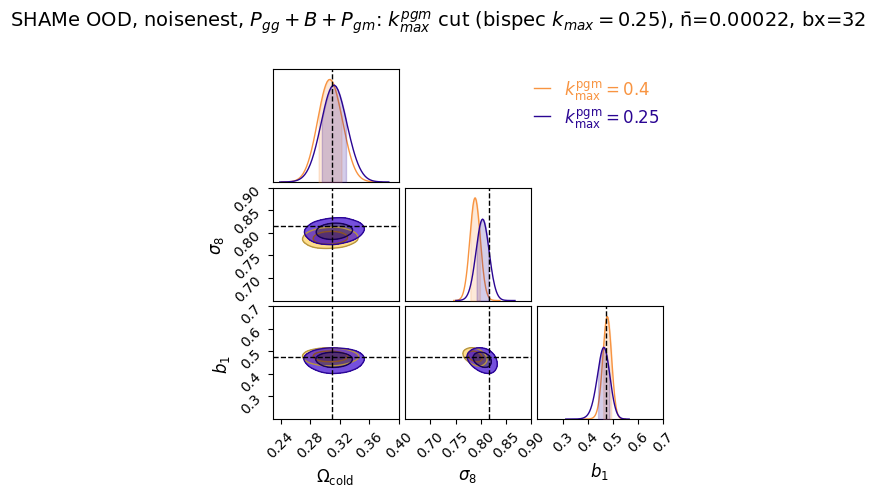

In [10]:
(
    tags_inf_ood_bp, labels_ood_bp, colors_ood_bp, tags_test_ood_bp, keep_ood_bp,
    *_,
) = setup_shame_ood(TAG_BIASPARAMS_TRAIN, STATISTICS_ARR_CMP_BSPEC_PGM, TAGS_MASK_CMP_BSPEC_PGM)
print_available("SHAMe OOD, noisenest — pk+bispec+pgm kpgm compare:", labels_ood_bp, tags_inf_ood_bp, tags_test_ood_bp, keep_ood_bp)

plot_kpgm_cmp_triangle(
    tags_inf_ood_bp, labels_ood_bp, colors_ood_bp, tags_test_ood_bp, keep_ood_bp,
    f"SHAMe OOD, noisenest, $P_{{gg}}+B+P_{{gm}}$: $k_{{max}}^{{pgm}}$ cut (bispec $k_{{max}}=0.25$), n̄={NBAR_LABEL}, bx={bx}",
    theta_zoom,
    tags_mask=TAGS_MASK_CMP_BSPEC_PGM,
)


## Individual phases

SHAMe OOD contours using **single-phase** summary statistics (`data{tag_mock}_phase0` / `_phasepi`), not the phase-averaged mock. Same fiducial four-statistic combinations as above ($P_{gg}$; $P_{gg}+P_{gm}$; $P_{gg}+B$ with $k_\text{max}^\text{bispec}=0.25$; $P_{gg}+B+P_{gm}$). Truth parameters use the base n̄ mock tag (bias is unchanged between phases).

**Phase overlay:** one triangle per stat combo with mean (grey), phase 0 (salmon), and phase $\pi$ (light teal).


SHAMe OOD, noisenest, $P_\mathrm{gg}(k)$, phases vs mean, n̄=0.00022, bx=32
  [x] mean: /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_nbar0.00022_pred.npy
  [x] phase $0$: /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_nbar0.00022_phase0_pred.npy
  [x] phase $\pi$: /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_nbar0.00022_phasepi_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_nbar0.00022_pred.npy
fn_samples = /scratch/kstoreyf/muchisim

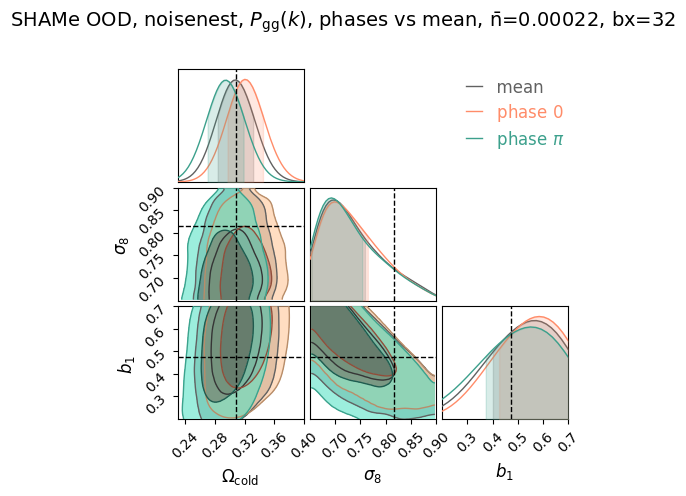


SHAMe OOD, noisenest, $P_\mathrm{gg}(k)$ + $P_\mathrm{gm}(k)$, phases vs mean, n̄=0.00022, bx=32
  [x] mean: /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_pgm_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_pgm_nbar0.00022_pred.npy
  [x] phase $0$: /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_pgm_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_pgm_nbar0.00022_phase0_pred.npy
  [x] phase $\pi$: /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_pgm_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_pgm_nbar0.00022_phasepi_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_pgm_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_pgm_nbar0.0

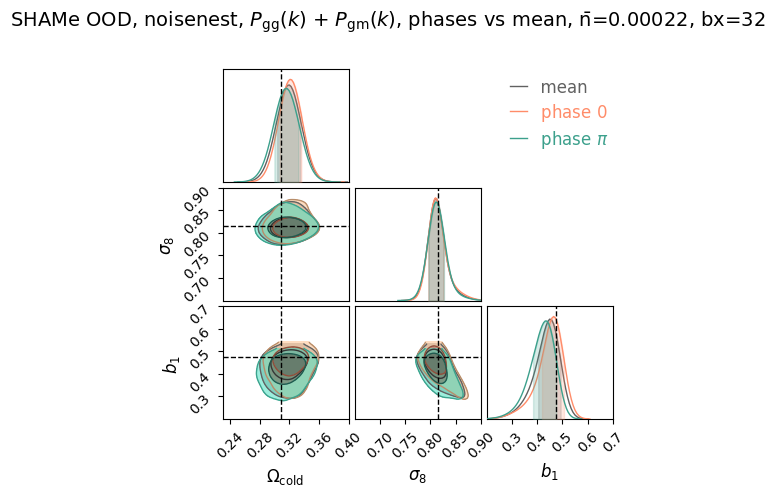


SHAMe OOD, noisenest, $P_\mathrm{gg}(k)$ + $B(k_1,k_2,k_3)$, phases vs mean, n̄=0.00022, bx=32
$k_\text{max}^\text{bispec}=0.25$
  [x] mean: /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_kb0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_bispec_kb0.25_nbar0.00022_pred.npy
  [x] phase $0$: /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_kb0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_bispec_kb0.25_nbar0.00022_phase0_pred.npy
  [x] phase $\pi$: /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_kb0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_bispec_kb0.25_nbar0.00022_phasepi_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_kb0.25_p5_n10000_biasnoise

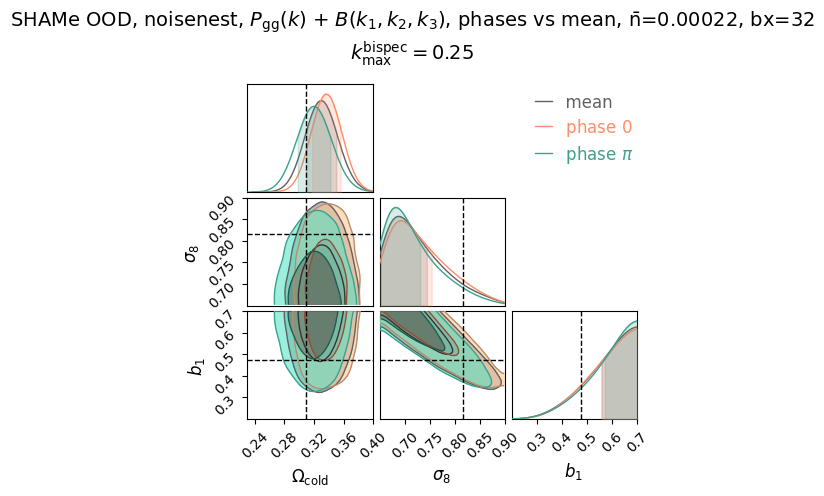


SHAMe OOD, noisenest, $P_\mathrm{gg}(k)$ + $B(k_1,k_2,k_3)$ + $P_\mathrm{gm}(k)$, phases vs mean, n̄=0.00022, bx=32
$k_\text{max}^\text{bispec}=0.25$
  [x] mean: /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kb0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_bispec_pgm_kb0.25_nbar0.00022_pred.npy
  [x] phase $0$: /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kb0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_bispec_pgm_kb0.25_nbar0.00022_phase0_pred.npy
  [x] phase $\pi$: /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kb0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_bispec_pgm_kb0.25_nbar0.00022_phasepi_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_much

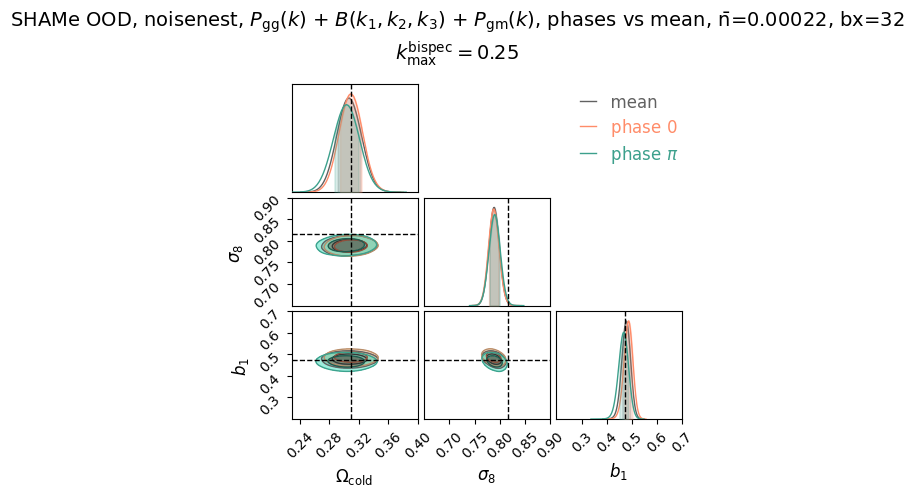

In [11]:
PHASE_OVERLAY_SPECS = [
    (TAG_MOCK_SHAME, "mean", "#616161"),
    (f"{TAG_MOCK_SHAME}_phase0", r"phase $0$", "#FF8C69"),
    (f"{TAG_MOCK_SHAME}_phasepi", r"phase $\pi$", "#3ca08c"),
]

cosmo_vary_ood, bias_vary_ood, param_vary_ood = utils_plot.load_training_params(
    TAG_PARAMS_TRAIN, TAG_BIASPARAMS_TRAIN, bx=bx,
)
theta_ood_overlay = data_loader.load_theta_ood(
    DATA_MODE_TEST_SHAME, TAG_MOCK_SHAME,
    cosmo_param_names_vary=cosmo_vary_ood, bias_param_names_vary=bias_vary_ood,
)
theta_obs_overlay = (
    theta_ood_overlay[idx_obs] if theta_ood_overlay.ndim == 2 else theta_ood_overlay
)
theta_zoom_overlay = theta_obs_overlay[
    [param_vary_ood.index(pn) for pn in PARAM_NAMES_ZOOM]
]

for statistics_row, tag_mask in zip(STATISTICS_ARR_FID, TAGS_MASK_FID):
    statistics_arr = [statistics_row]
    tags_mask = [tag_mask]
    tags_inf_one, _, _ = setup_inference(
        TAG_BIASPARAMS_TRAIN, statistics_arr, tags_mask,
    )
    tag_inf = tags_inf_one[0]
    stat_stats = tag_stats_arr(statistics_arr, tags_mask)

    tags_inf_plot, tags_test_plot, colors_plot, labels_plot = [], [], [], []
    for tag_mock_var, phase_label, color in PHASE_OVERLAY_SPECS:
        tags_test = utils_plot.setup_shame_mock_test_tags(
            tag_stats_arr=stat_stats,
            data_mode_test=DATA_MODE_TEST_SHAME,
            tag_mock=tag_mock_var,
        )
        if sample_fn(tag_inf, tags_test[0]).exists():
            tags_inf_plot.append(tag_inf)
            tags_test_plot.append(tags_test[0])
            colors_plot.append(color)
            labels_plot.append(phase_label)

    stat_lbl = utils_plot.get_stat_label(statistics_row)
    mask_lbl = utils_plot.get_mask_label(tag_mask)
    title = f"SHAMe OOD, noisenest, {stat_lbl}, phases vs mean, n̄={NBAR_LABEL}, bx={bx}"
    if mask_lbl:
        title = f"{title}\n{mask_lbl}"

    print(f"\n{title}")
    for lbl, tt in zip(labels_plot, tags_test_plot):
        print(f"  [x] {lbl}: {sample_fn(tag_inf, tt)}")
    for tag_mock_var, phase_label, _ in PHASE_OVERLAY_SPECS:
        tags_test = utils_plot.setup_shame_mock_test_tags(
            tag_stats_arr=stat_stats,
            data_mode_test=DATA_MODE_TEST_SHAME,
            tag_mock=tag_mock_var,
        )
        if not sample_fn(tag_inf, tags_test[0]).exists():
            print(f"  [ ] {phase_label}: {sample_fn(tag_inf, tags_test[0])}")

    if len(tags_inf_plot) < 2:
        print("  skip plot (need at least two of mean / phase0 / phaseπ)")
        continue

    plotter.plot_contours_inf(
        param_names=PARAM_NAMES_ZOOM,
        idx_obs=idx_obs,
        theta_obs_true=theta_zoom_overlay,
        inf_methods=["sbi"] * len(tags_inf_plot),
        tags_inf=tags_inf_plot,
        tags_test=tags_test_plot,
        colors=colors_plot,
        labels=labels_plot,
        title=title,
        extents=extents_noisebest_fid,
        figsize=FIGSIZE_CORNER,
        fontsize_legend=FONTSIZE_LEGEND,
        loc_legend=LOC_LEGEND,
        unreparameterize=True,
    )

# Fixed cosmo mean — noisebest

## Contours

In [18]:
(
    tags_inf_nb, labels_nb, colors_nb, tags_test_nb, keep_nb,
    theta_obs_nb, theta_zoom_nb, param_vary_nb,
) = setup_fixed_mean(
    TAG_BIASPARAMS_TRAIN,
    TAG_BIASPARAMS_TEST,
    STATISTICS_ARR_FID,
    TAGS_MASK_FID,
)
inf_nb = ["sbi"] * len(tags_inf_nb)
print_available("Fixed cosmo mean, noisebest — fiducial:", labels_nb, tags_inf_nb, tags_test_nb, keep_nb)


Fixed cosmo mean, noisebest — fiducial:
  [x] $P_\mathrm{gg}(k)$
  [x] $P_\mathrm{gg}(k)$ + $P_\mathrm{gm}(k)$
  [x] $P_\mathrm{gg}(k)$ + $B(k_1,k_2,k_3)$
  [x] $P_\mathrm{gg}(k)$ + $B(k_1,k_2,k_3)$ + $P_\mathrm{gm}(k)$


fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_shame_p0_n1000_bias_shame_noisebest_p0_n1_noise_unit_shame_p0_n1000_mean_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_pgm_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_pgm_shame_p0_n1000_bias_shame_noisebest_p0_n1_noise_unit_shame_p0_n1000_mean_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_kb0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_bispec_kb0.25_shame_p0_n1000_bias_shame_noisebest_p0_n1_noise_unit_shame_p0_n1000_mean_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kb0.25_p5_n10000_bia

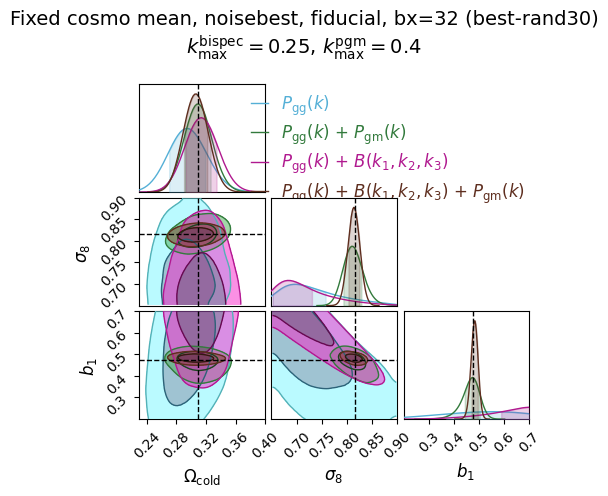

In [19]:
plot_fiducial_triangle(
    tags_inf_nb, labels_nb, colors_nb, tags_test_nb, keep_nb,
    f"Fixed cosmo mean, noisebest, fiducial, bx={bx} (best-rand30)",
    theta_zoom_nb,
    tags_mask=TAGS_MASK_FID,
    extents=extents_noisebest_fid,
)


### All varied parameters (fiducial)


fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_shame_p0_n1000_bias_shame_noisebest_p0_n1_noise_unit_shame_p0_n1000_mean_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_pgm_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_pgm_shame_p0_n1000_bias_shame_noisebest_p0_n1_noise_unit_shame_p0_n1000_mean_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_kb0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_bispec_kb0.25_shame_p0_n1000_bias_shame_noisebest_p0_n1_noise_unit_shame_p0_n1000_mean_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kb0.25_p5_n10000_bia

Parameter b2 in chain $P_\mathrm{gg}(k)$ is not constrained
Parameter An_homog in chain $P_\mathrm{gg}(k)$ + $B(k_1,k_2,k_3)$ is not constrained
Parameter An_homog in chain $P_\mathrm{gg}(k)$ + $B(k_1,k_2,k_3)$ + $P_\mathrm{gm}(k)$ is not constrained
Parameter An_b1 in chain $P_\mathrm{gg}(k)$ + $B(k_1,k_2,k_3)$ + $P_\mathrm{gm}(k)$ is not constrained


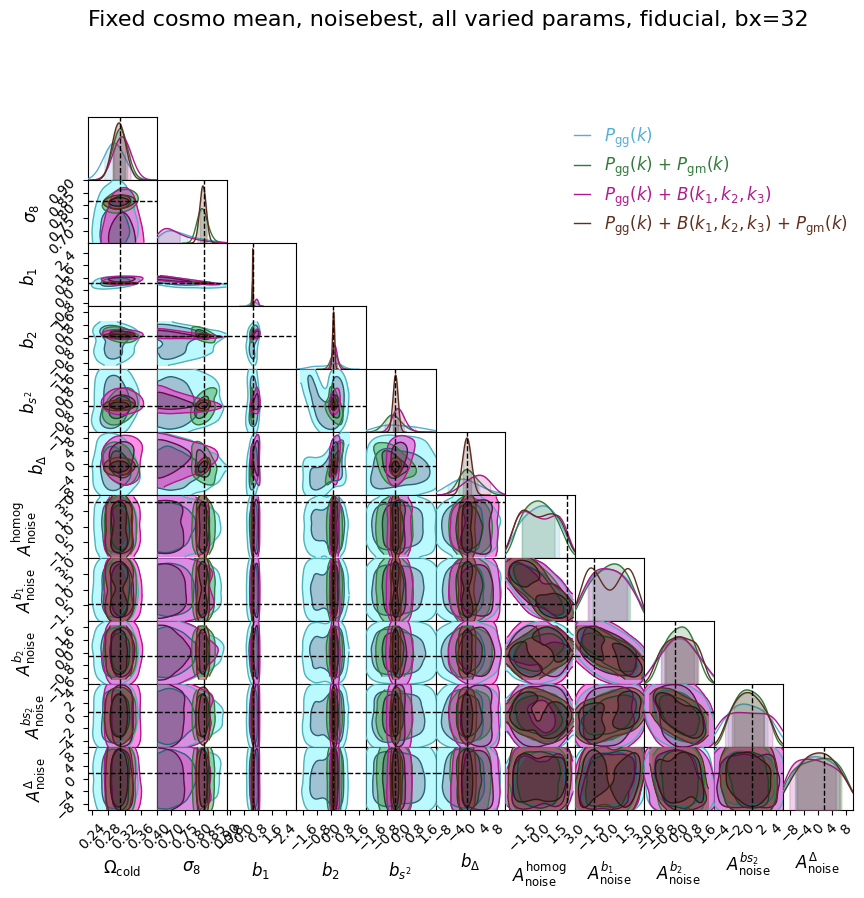

In [20]:
plot_all_params_fiducial(
    tags_inf_nb, labels_nb, colors_nb, tags_test_nb, keep_nb,
    f"Fixed cosmo mean, noisebest, all varied params, fiducial, bx={bx}",
    theta_obs_nb, param_vary_nb,
)


## $k_\mathrm{max}$ sweeps

Triangle overlays for **noisebest** fixed-cosmo tests. Only chains with samples on disk are plotted.
- $P_{gg}+P_{gm}$ and $P_{gg}+B$: 1D sweeps ($k_\mathrm{max}$ from 0.1 to loose).
- $P_{gg}+B+P_{gm}$: 2D grid ($k_\mathrm{max}$ from 0.2 to loose); separate plots with bispec or pgm held fixed.


### $P_{gg}+P_{gm}$: sweep $k_\mathrm{max}^\mathrm{pgm}$ (0.1 → loose)


Fixed cosmo mean, noisebest, $P_{gg}+P_{gm}$: sweep $k_{max}^{pgm}$, bx=32 — availability:
  [x] $P_\mathrm{gg}(k)$ + $P_\mathrm{gm}(k)$
  [x] $P_\mathrm{gg}(k)$ + $P_\mathrm{gm}(k)$
  [x] $P_\mathrm{gg}(k)$ + $P_\mathrm{gm}(k)$
  [x] $P_\mathrm{gg}(k)$ + $P_\mathrm{gm}(k)$
  [x] $P_\mathrm{gg}(k)$ + $P_\mathrm{gm}(k)$
  [x] $P_\mathrm{gg}(k)$ + $P_\mathrm{gm}(k)$
  [x] $P_\mathrm{gg}(k)$ + $P_\mathrm{gm}(k)$
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_pgm_kpgm0.1_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_pgm_kpgm0.1_shame_p0_n1000_bias_shame_noisebest_p0_n1_noise_unit_shame_p0_n1000_mean_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_pgm_kpgm0.15_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_pgm_kpgm0.15_shame_p0_n1000_bias_shame_noisebest_p0_n1_noise_unit_

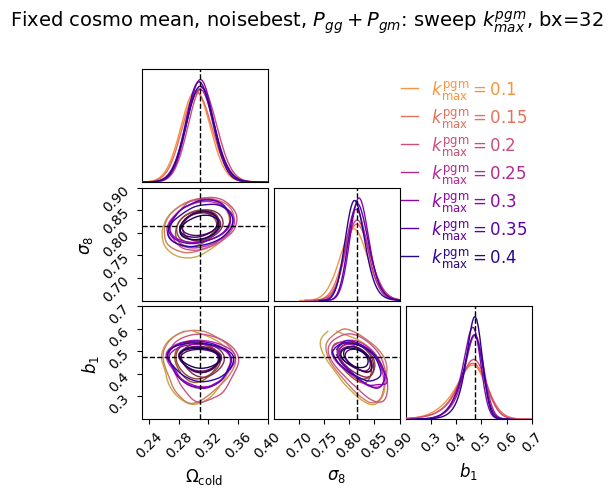

In [16]:
plot_kmax_sweep_fixed(
    STAT_ROW_PGM,
    TAGS_KMAX_KPGM_1D,
    f"Fixed cosmo mean, noisebest, $P_{{gg}}+P_{{gm}}$: sweep $k_{{max}}^{{pgm}}$, bx={bx}",
    theta_zoom_nb,
    kmax_focus="pgm",
)


### $P_{gg}+B$: sweep $k_\mathrm{max}^\mathrm{bispec}$ (0.1 → loose)


Fixed cosmo mean, noisebest, $P_{gg}+B$: sweep $k_{max}^{bispec}$, bx=32 — availability:
  [x] $P_\mathrm{gg}(k)$ + $B(k_1,k_2,k_3)$
  [x] $P_\mathrm{gg}(k)$ + $B(k_1,k_2,k_3)$
  [x] $P_\mathrm{gg}(k)$ + $B(k_1,k_2,k_3)$
  [x] $P_\mathrm{gg}(k)$ + $B(k_1,k_2,k_3)$
  [x] $P_\mathrm{gg}(k)$ + $B(k_1,k_2,k_3)$
  [x] $P_\mathrm{gg}(k)$ + $B(k_1,k_2,k_3)$
  [x] $P_\mathrm{gg}(k)$ + $B(k_1,k_2,k_3)$
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_kb0.1_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_bispec_kb0.1_shame_p0_n1000_bias_shame_noisebest_p0_n1_noise_unit_shame_p0_n1000_mean_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_kb0.15_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_bispec_kb0.15_shame_p0_n1000_bias_shame_noisebest_p0_n1_noise_unit_shame_p0_n10

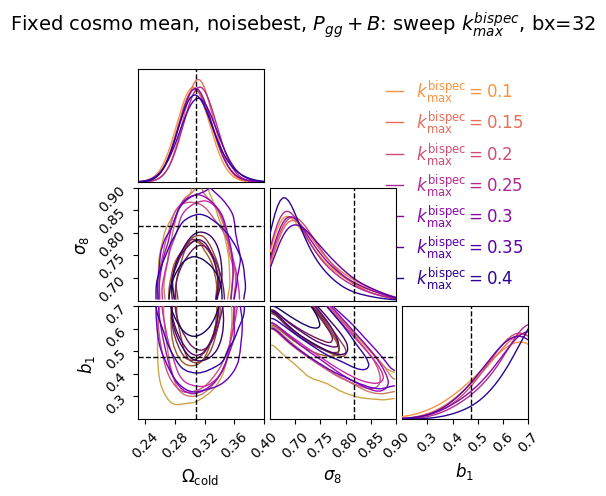

In [17]:
plot_kmax_sweep_fixed(
    STAT_ROW_KB,
    TAGS_KMAX_KB_1D,
    f"Fixed cosmo mean, noisebest, $P_{{gg}}+B$: sweep $k_{{max}}^{{bispec}}$, bx={bx}",
    theta_zoom_nb,
    kmax_focus="bispec",
)


### $P_{gg}+B+P_{gm}$: 2D grid (fix bispec $k_\mathrm{max}$, sweep pgm)

One triangle per fixed $k_\mathrm{max}^\mathrm{bispec}$; legend shows varying $k_\mathrm{max}^\mathrm{pgm}$.


Fixed cosmo mean, noisebest, $P_{gg}+B+P_{gm}$: $k_\text{max}^\text{bispec}=0.2$ fixed, sweep $k_{max}^{pgm}$, bx=32 — availability:
  [x] $P_\mathrm{gg}(k)$ + $B(k_1,k_2,k_3)$ + $P_\mathrm{gm}(k)$
  [x] $P_\mathrm{gg}(k)$ + $B(k_1,k_2,k_3)$ + $P_\mathrm{gm}(k)$
  [x] $P_\mathrm{gg}(k)$ + $B(k_1,k_2,k_3)$ + $P_\mathrm{gm}(k)$
  [x] $P_\mathrm{gg}(k)$ + $B(k_1,k_2,k_3)$ + $P_\mathrm{gm}(k)$
  [x] $P_\mathrm{gg}(k)$ + $B(k_1,k_2,k_3)$ + $P_\mathrm{gm}(k)$
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kb0.2_kpgm0.2_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_bispec_pgm_kb0.2_kpgm0.2_shame_p0_n1000_bias_shame_noisebest_p0_n1_noise_unit_shame_p0_n1000_mean_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kb0.2_kpgm0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_tes

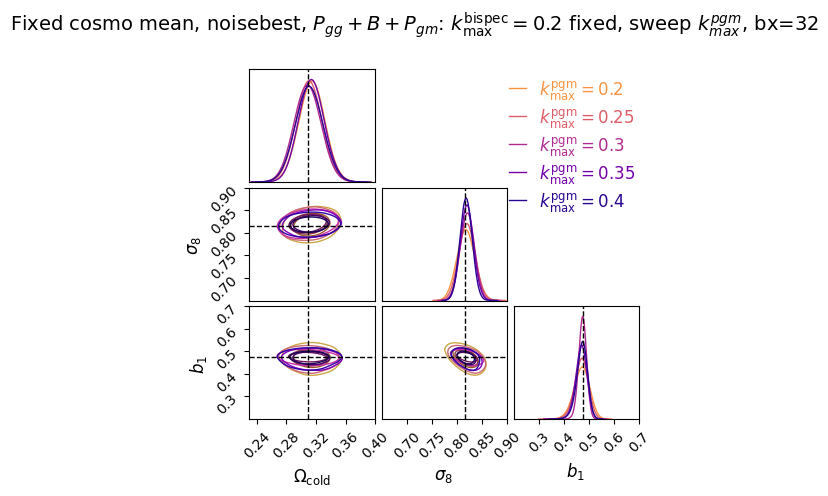

Fixed cosmo mean, noisebest, $P_{gg}+B+P_{gm}$: $k_\text{max}^\text{bispec}=0.25$ fixed, sweep $k_{max}^{pgm}$, bx=32 — availability:
  [x] $P_\mathrm{gg}(k)$ + $B(k_1,k_2,k_3)$ + $P_\mathrm{gm}(k)$
  [x] $P_\mathrm{gg}(k)$ + $B(k_1,k_2,k_3)$ + $P_\mathrm{gm}(k)$
  [x] $P_\mathrm{gg}(k)$ + $B(k_1,k_2,k_3)$ + $P_\mathrm{gm}(k)$
  [x] $P_\mathrm{gg}(k)$ + $B(k_1,k_2,k_3)$ + $P_\mathrm{gm}(k)$
  [x] $P_\mathrm{gg}(k)$ + $B(k_1,k_2,k_3)$ + $P_\mathrm{gm}(k)$
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kb0.25_kpgm0.2_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_bispec_pgm_kb0.25_kpgm0.2_shame_p0_n1000_bias_shame_noisebest_p0_n1_noise_unit_shame_p0_n1000_mean_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kb0.25_kpgm0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples

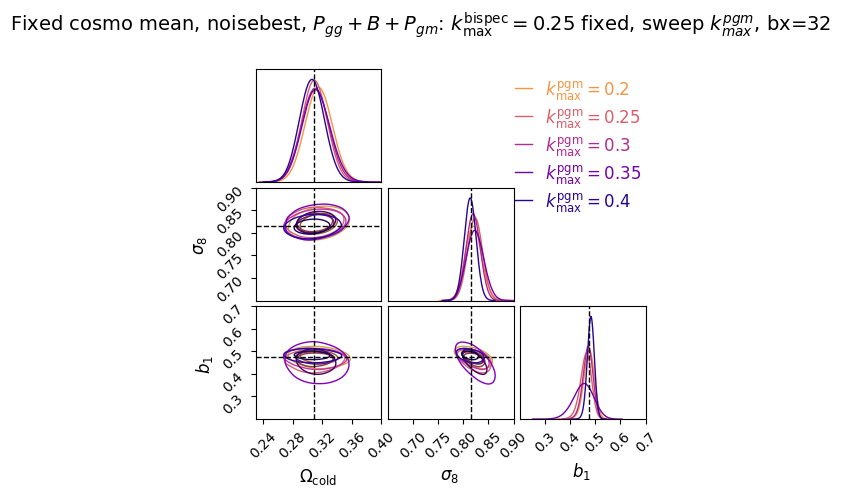

Fixed cosmo mean, noisebest, $P_{gg}+B+P_{gm}$: $k_\text{max}^\text{bispec}=0.3$ fixed, sweep $k_{max}^{pgm}$, bx=32 — availability:
  [x] $P_\mathrm{gg}(k)$ + $B(k_1,k_2,k_3)$ + $P_\mathrm{gm}(k)$
  [x] $P_\mathrm{gg}(k)$ + $B(k_1,k_2,k_3)$ + $P_\mathrm{gm}(k)$
  [x] $P_\mathrm{gg}(k)$ + $B(k_1,k_2,k_3)$ + $P_\mathrm{gm}(k)$
  [x] $P_\mathrm{gg}(k)$ + $B(k_1,k_2,k_3)$ + $P_\mathrm{gm}(k)$
  [x] $P_\mathrm{gg}(k)$ + $B(k_1,k_2,k_3)$ + $P_\mathrm{gm}(k)$
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kb0.3_kpgm0.2_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_bispec_pgm_kb0.3_kpgm0.2_shame_p0_n1000_bias_shame_noisebest_p0_n1_noise_unit_shame_p0_n1000_mean_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kb0.3_kpgm0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_tes

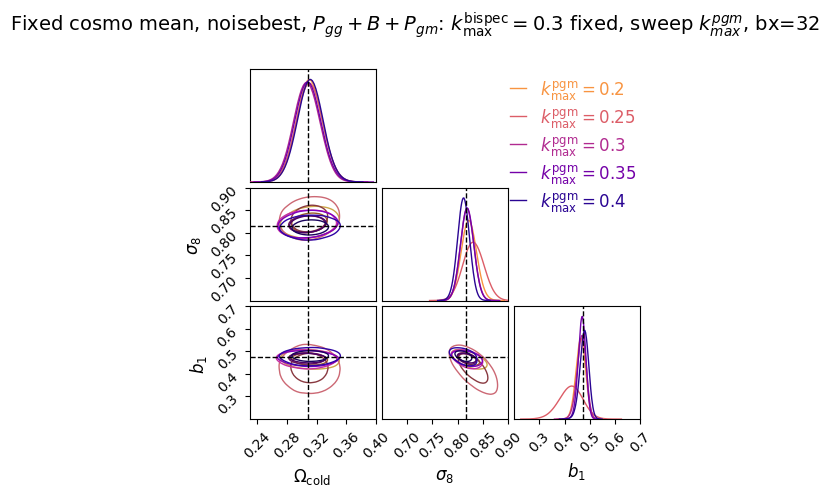

Fixed cosmo mean, noisebest, $P_{gg}+B+P_{gm}$: $k_\text{max}^\text{bispec}=0.35$ fixed, sweep $k_{max}^{pgm}$, bx=32 — availability:
  [x] $P_\mathrm{gg}(k)$ + $B(k_1,k_2,k_3)$ + $P_\mathrm{gm}(k)$
  [x] $P_\mathrm{gg}(k)$ + $B(k_1,k_2,k_3)$ + $P_\mathrm{gm}(k)$
  [x] $P_\mathrm{gg}(k)$ + $B(k_1,k_2,k_3)$ + $P_\mathrm{gm}(k)$
  [x] $P_\mathrm{gg}(k)$ + $B(k_1,k_2,k_3)$ + $P_\mathrm{gm}(k)$
  [x] $P_\mathrm{gg}(k)$ + $B(k_1,k_2,k_3)$ + $P_\mathrm{gm}(k)$
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kb0.35_kpgm0.2_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_bispec_pgm_kb0.35_kpgm0.2_shame_p0_n1000_bias_shame_noisebest_p0_n1_noise_unit_shame_p0_n1000_mean_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kb0.35_kpgm0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples

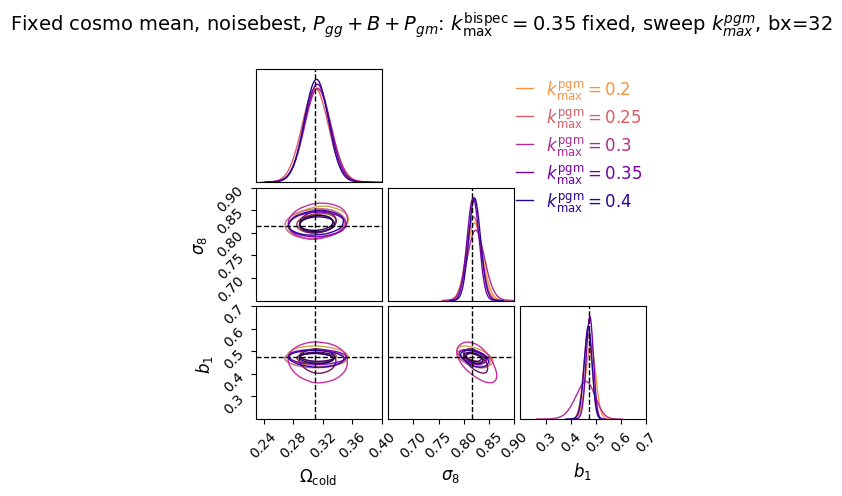

Fixed cosmo mean, noisebest, $P_{gg}+B+P_{gm}$: $k_\text{max}^\text{bispec}=0.4$ fixed, sweep $k_{max}^{pgm}$, bx=32 — availability:
  [x] $P_\mathrm{gg}(k)$ + $B(k_1,k_2,k_3)$ + $P_\mathrm{gm}(k)$
  [x] $P_\mathrm{gg}(k)$ + $B(k_1,k_2,k_3)$ + $P_\mathrm{gm}(k)$
  [x] $P_\mathrm{gg}(k)$ + $B(k_1,k_2,k_3)$ + $P_\mathrm{gm}(k)$
  [x] $P_\mathrm{gg}(k)$ + $B(k_1,k_2,k_3)$ + $P_\mathrm{gm}(k)$
  [x] $P_\mathrm{gg}(k)$ + $B(k_1,k_2,k_3)$ + $P_\mathrm{gm}(k)$
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kpgm0.2_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_bispec_pgm_kpgm0.2_shame_p0_n1000_bias_shame_noisebest_p0_n1_noise_unit_shame_p0_n1000_mean_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kpgm0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_

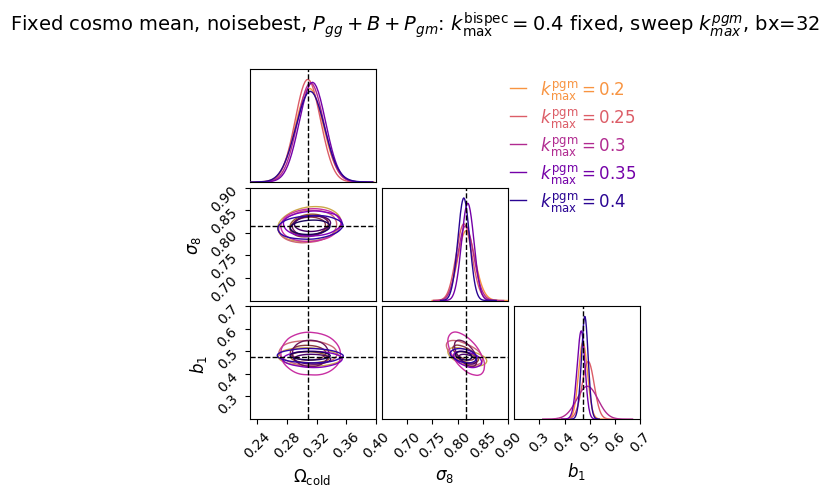

In [18]:
for tag_kb in TAG_GRID_KB:
    masks = [join_kmax_masks(tag_kb, tag_kpgm) for tag_kpgm in TAG_GRID_KPGM]
    kb_lbl = _kmax_focus_label(tag_kb, "bispec")
    plot_kmax_sweep_fixed(
        STAT_ROW_BPGM,
        masks,
        f"Fixed cosmo mean, noisebest, $P_{{gg}}+B+P_{{gm}}$: {kb_lbl} fixed, sweep $k_{{max}}^{{pgm}}$, bx={bx}",
        theta_zoom_nb,
        kmax_focus="pgm",
    )


### $P_{gg}+B+P_{gm}$: 2D grid (fix pgm $k_\mathrm{max}$, sweep bispec)

One triangle per fixed $k_\mathrm{max}^\mathrm{pgm}$; legend shows varying $k_\mathrm{max}^\mathrm{bispec}$.


Fixed cosmo mean, noisebest, $P_{gg}+B+P_{gm}$: $k_\text{max}^\text{pgm}=0.2$ fixed, sweep $k_{max}^{bispec}$, bx=32 — availability:
  [x] $P_\mathrm{gg}(k)$ + $B(k_1,k_2,k_3)$ + $P_\mathrm{gm}(k)$
  [x] $P_\mathrm{gg}(k)$ + $B(k_1,k_2,k_3)$ + $P_\mathrm{gm}(k)$
  [x] $P_\mathrm{gg}(k)$ + $B(k_1,k_2,k_3)$ + $P_\mathrm{gm}(k)$
  [x] $P_\mathrm{gg}(k)$ + $B(k_1,k_2,k_3)$ + $P_\mathrm{gm}(k)$
  [x] $P_\mathrm{gg}(k)$ + $B(k_1,k_2,k_3)$ + $P_\mathrm{gm}(k)$
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kb0.2_kpgm0.2_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_bispec_pgm_kb0.2_kpgm0.2_shame_p0_n1000_bias_shame_noisebest_p0_n1_noise_unit_shame_p0_n1000_mean_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kb0.25_kpgm0.2_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_tes

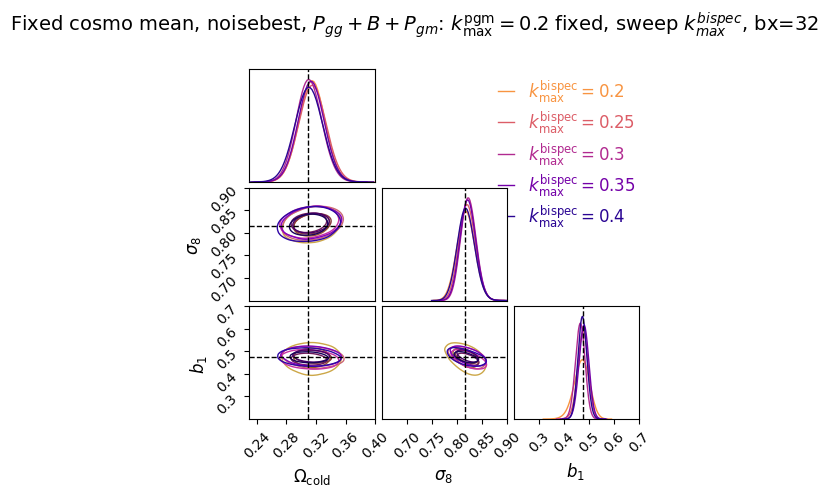

Fixed cosmo mean, noisebest, $P_{gg}+B+P_{gm}$: $k_\text{max}^\text{pgm}=0.25$ fixed, sweep $k_{max}^{bispec}$, bx=32 — availability:
  [x] $P_\mathrm{gg}(k)$ + $B(k_1,k_2,k_3)$ + $P_\mathrm{gm}(k)$
  [x] $P_\mathrm{gg}(k)$ + $B(k_1,k_2,k_3)$ + $P_\mathrm{gm}(k)$
  [x] $P_\mathrm{gg}(k)$ + $B(k_1,k_2,k_3)$ + $P_\mathrm{gm}(k)$
  [x] $P_\mathrm{gg}(k)$ + $B(k_1,k_2,k_3)$ + $P_\mathrm{gm}(k)$
  [x] $P_\mathrm{gg}(k)$ + $B(k_1,k_2,k_3)$ + $P_\mathrm{gm}(k)$
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kb0.2_kpgm0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_bispec_pgm_kb0.2_kpgm0.25_shame_p0_n1000_bias_shame_noisebest_p0_n1_noise_unit_shame_p0_n1000_mean_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kb0.25_kpgm0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples

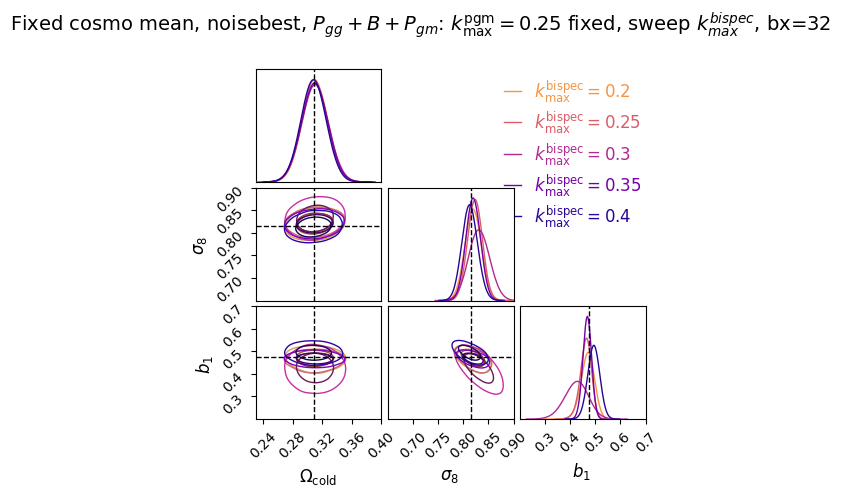

Fixed cosmo mean, noisebest, $P_{gg}+B+P_{gm}$: $k_\text{max}^\text{pgm}=0.3$ fixed, sweep $k_{max}^{bispec}$, bx=32 — availability:
  [x] $P_\mathrm{gg}(k)$ + $B(k_1,k_2,k_3)$ + $P_\mathrm{gm}(k)$
  [x] $P_\mathrm{gg}(k)$ + $B(k_1,k_2,k_3)$ + $P_\mathrm{gm}(k)$
  [x] $P_\mathrm{gg}(k)$ + $B(k_1,k_2,k_3)$ + $P_\mathrm{gm}(k)$
  [x] $P_\mathrm{gg}(k)$ + $B(k_1,k_2,k_3)$ + $P_\mathrm{gm}(k)$
  [x] $P_\mathrm{gg}(k)$ + $B(k_1,k_2,k_3)$ + $P_\mathrm{gm}(k)$
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kb0.2_kpgm0.3_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_bispec_pgm_kb0.2_kpgm0.3_shame_p0_n1000_bias_shame_noisebest_p0_n1_noise_unit_shame_p0_n1000_mean_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kb0.25_kpgm0.3_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_tes

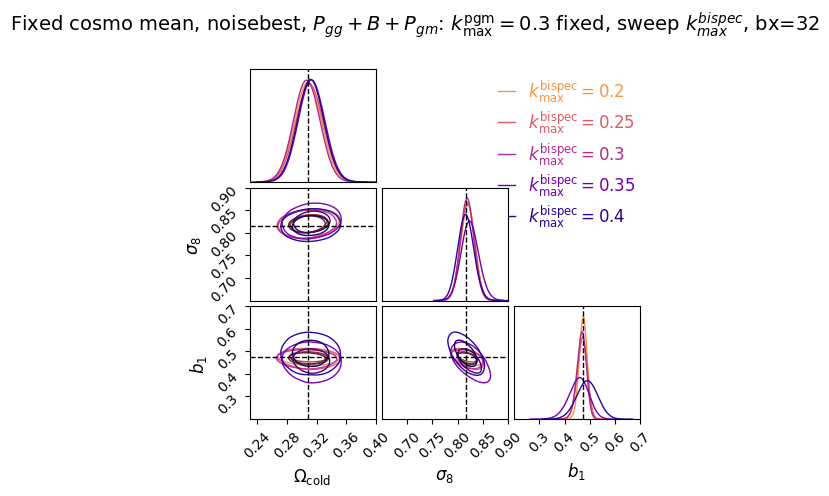

Fixed cosmo mean, noisebest, $P_{gg}+B+P_{gm}$: $k_\text{max}^\text{pgm}=0.35$ fixed, sweep $k_{max}^{bispec}$, bx=32 — availability:
  [x] $P_\mathrm{gg}(k)$ + $B(k_1,k_2,k_3)$ + $P_\mathrm{gm}(k)$
  [x] $P_\mathrm{gg}(k)$ + $B(k_1,k_2,k_3)$ + $P_\mathrm{gm}(k)$
  [x] $P_\mathrm{gg}(k)$ + $B(k_1,k_2,k_3)$ + $P_\mathrm{gm}(k)$
  [x] $P_\mathrm{gg}(k)$ + $B(k_1,k_2,k_3)$ + $P_\mathrm{gm}(k)$
  [x] $P_\mathrm{gg}(k)$ + $B(k_1,k_2,k_3)$ + $P_\mathrm{gm}(k)$
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kb0.2_kpgm0.35_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_bispec_pgm_kb0.2_kpgm0.35_shame_p0_n1000_bias_shame_noisebest_p0_n1_noise_unit_shame_p0_n1000_mean_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kb0.25_kpgm0.35_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples

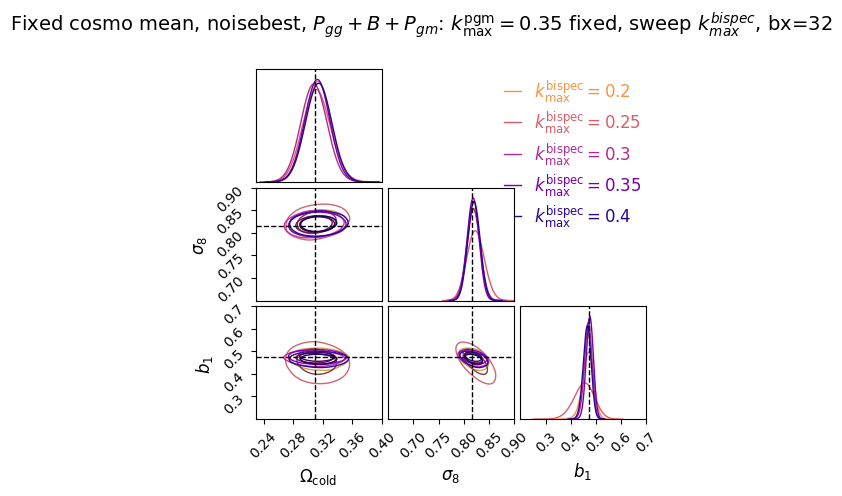

Fixed cosmo mean, noisebest, $P_{gg}+B+P_{gm}$: $k_\text{max}^\text{pgm}=0.4$ fixed, sweep $k_{max}^{bispec}$, bx=32 — availability:
  [x] $P_\mathrm{gg}(k)$ + $B(k_1,k_2,k_3)$ + $P_\mathrm{gm}(k)$
  [x] $P_\mathrm{gg}(k)$ + $B(k_1,k_2,k_3)$ + $P_\mathrm{gm}(k)$
  [x] $P_\mathrm{gg}(k)$ + $B(k_1,k_2,k_3)$ + $P_\mathrm{gm}(k)$
  [x] $P_\mathrm{gg}(k)$ + $B(k_1,k_2,k_3)$ + $P_\mathrm{gm}(k)$
  [x] $P_\mathrm{gg}(k)$ + $B(k_1,k_2,k_3)$ + $P_\mathrm{gm}(k)$
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kb0.2_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_bispec_pgm_kb0.2_shame_p0_n1000_bias_shame_noisebest_p0_n1_noise_unit_shame_p0_n1000_mean_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kb0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_bispec

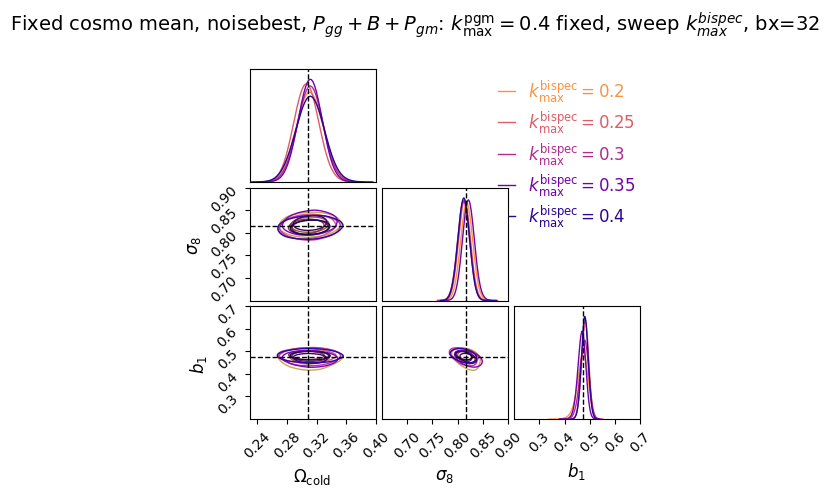

In [19]:
for tag_kpgm in TAG_GRID_KPGM:
    masks = [join_kmax_masks(tag_kb, tag_kpgm) for tag_kb in TAG_GRID_KB]
    pgm_lbl = _kmax_focus_label(tag_kpgm, "pgm")
    plot_kmax_sweep_fixed(
        STAT_ROW_BPGM,
        masks,
        f"Fixed cosmo mean, noisebest, $P_{{gg}}+B+P_{{gm}}$: {pgm_lbl} fixed, sweep $k_{{max}}^{{bispec}}$, bx={bx}",
        theta_zoom_nb,
        kmax_focus="bispec",
    )
